In [7]:
import torch
from model import TimeSeriesTransformer
from dataset import SolarLSTMDataset
import pandas as pd
import torch.nn as nn

In [3]:
df = pd.read_csv("dataset/final.csv")

In [5]:
import numpy as np
import matplotlib.pyplot as plt

counts, bin_edges = np.histogram(df["ALLSKY_SFC_SW_DWN"], bins=50)
hist_dict = {
    "bin_edges": bin_edges.tolist(),
    "counts": counts.tolist()
}


In [30]:
import joblib
import pandas as pd
from dataset import SolarLSTMDataset

# Load your preprocessed dataset
df = pd.read_csv("dataset/final.csv")  # replace with your full dataset path
df['datetime'] = pd.to_datetime( df['datetime'])
# Create dataset instance (this fits the scaler inside)
dataset = SolarLSTMDataset(df)

# Save the fitted scaler
joblib.dump(dataset.scaler, "scalers/feature_scaler.pkl")

print("✅ Scaler saved to scalers/feature_scaler.pkl")


✅ Scaler saved to scalers/feature_scaler.pkl


In [6]:
hist_dict

{'bin_edges': [-999.0,
  -957.9436000000001,
  -916.8872,
  -875.8308,
  -834.7744,
  -793.7180000000001,
  -752.6616,
  -711.6052,
  -670.5488,
  -629.4924000000001,
  -588.436,
  -547.3796,
  -506.32320000000004,
  -465.2668000000001,
  -424.21040000000005,
  -383.154,
  -342.09760000000006,
  -301.0412000000001,
  -259.98480000000006,
  -218.9284,
  -177.87200000000007,
  -136.81560000000013,
  -95.75920000000008,
  -54.702800000000025,
  -13.646400000000085,
  27.409999999999854,
  68.4663999999998,
  109.52279999999996,
  150.5791999999999,
  191.63559999999984,
  232.692,
  273.74839999999995,
  314.8047999999999,
  355.8611999999998,
  396.91759999999977,
  437.97399999999993,
  479.0303999999999,
  520.0867999999998,
  561.1432,
  602.1995999999999,
  643.2559999999999,
  684.3123999999998,
  725.3687999999997,
  766.4251999999999,
  807.4815999999998,
  848.5379999999998,
  889.5944,
  930.6507999999999,
  971.7071999999998,
  1012.7635999999998,
  1053.82],
 'counts': [61560,

In [9]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [10]:
def train_model(model, train_loader, val_loader, data,epochs=20, lr=0.001, device='cuda',offset = 0):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            preds = model(X)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X.size(0)
        
        train_loss /= len(train_loader.dataset)

        val_loss = evaluate_model(model, val_loader, criterion, device)
        data[epoch+offset]=train_loss
        print(f"Epoch {epoch+1+offset}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

def evaluate_model(model, val_loader, criterion, device='cuda'):
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            preds = model(X)
            loss = criterion(preds, y)
            val_loss += loss.item() * X.size(0)
    return val_loss / len(val_loader.dataset)


In [11]:
from torch.utils.data import DataLoader, random_split
import pandas as pd
dataset = SolarLSTMDataset(df, seq_len=24)

# Split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

# Model
input_size = dataset.X.shape[2]
model = TimeSeriesTransformer(input_size=input_size)

# Train


a:\weather_net\dataset.py:45: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  self.X = torch.tensor(self.X, dtype=torch.float32)


In [11]:
dataset.X.shape

torch.Size([87791, 24, 14])

In [12]:
data ={}

In [14]:

train_model(model, train_loader, val_loader, epochs=10, lr=0.01,data=data,offset=len(data))


Epoch 6: Train Loss = 10243.7832, Val Loss = 2245.2043
Epoch 7: Train Loss = 8641.8494, Val Loss = 2190.4346
Epoch 8: Train Loss = 7943.4656, Val Loss = 2042.6183
Epoch 9: Train Loss = 7431.3351, Val Loss = 1910.3610
Epoch 10: Train Loss = 6834.6580, Val Loss = 1706.8906
Epoch 11: Train Loss = 6323.6627, Val Loss = 2117.4053
Epoch 12: Train Loss = 6012.4971, Val Loss = 1782.8093
Epoch 13: Train Loss = 5735.0926, Val Loss = 1781.3907
Epoch 14: Train Loss = 5523.5917, Val Loss = 1700.8170
Epoch 15: Train Loss = 5314.5855, Val Loss = 1692.6365


In [49]:
import matplotlib.pyplot as plt

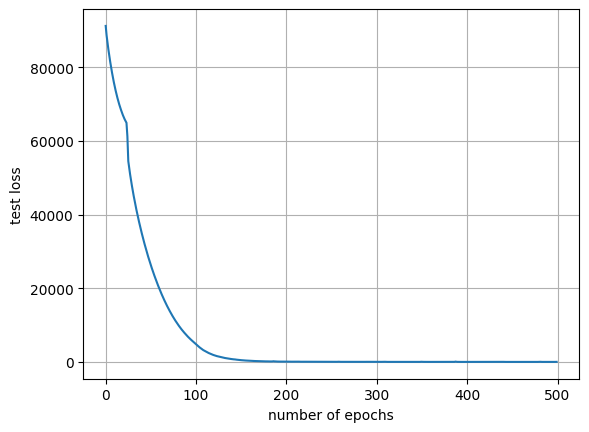

In [52]:
plt.plot(list(data.keys()),list(data.values()))
plt.xlabel("number of epochs")
plt.ylabel("test loss")
plt.grid(True)

In [53]:
torch.save(model.state_dict(),"models/version2.pth")

In [57]:
loss_fn = nn.MSELoss()

In [60]:
with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to('cuda'), y.to('cuda')
        preds = model(X)
        print(preds[0])
        loss = loss_fn(preds, y)


tensor([171.0810], device='cuda:0')
tensor([755.2513], device='cuda:0')
tensor([0.0577], device='cuda:0')
tensor([-0.9592], device='cuda:0')
tensor([101.6121], device='cuda:0')
tensor([616.3111], device='cuda:0')
tensor([-0.9835], device='cuda:0')
tensor([366.2784], device='cuda:0')
tensor([-0.1612], device='cuda:0')
tensor([190.4381], device='cuda:0')
tensor([-0.9851], device='cuda:0')
tensor([-0.4384], device='cuda:0')
tensor([894.7984], device='cuda:0')
tensor([-0.3301], device='cuda:0')
tensor([-1.1211], device='cuda:0')
tensor([396.7848], device='cuda:0')
tensor([124.4957], device='cuda:0')
tensor([-0.5442], device='cuda:0')
tensor([-0.9899], device='cuda:0')
tensor([505.3874], device='cuda:0')
tensor([718.7461], device='cuda:0')
tensor([586.3856], device='cuda:0')
tensor([-0.3217], device='cuda:0')
tensor([286.5681], device='cuda:0')
tensor([18.1698], device='cuda:0')
tensor([24.6909], device='cuda:0')
tensor([-0.8661], device='cuda:0')
tensor([-0.0263], device='cuda:0')


In [12]:
model = TimeSeriesTransformer(dataset.X.shape[2])

In [33]:
model.load_state_dict(torch.load("models/version2.pth"))

C:\Users\grins\AppData\Local\Temp\ipykernel_3712\3839182896.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("models/version2.pth"))


<All keys matched successfully>

In [31]:
from eval import evaluate_and_plot

In [34]:
model.to('cuda')

TimeSeriesTransformer(
  (input_proj): Linear(in_features=14, out_features=128, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features

RMSE: 24.0507
MAE : 15.5210


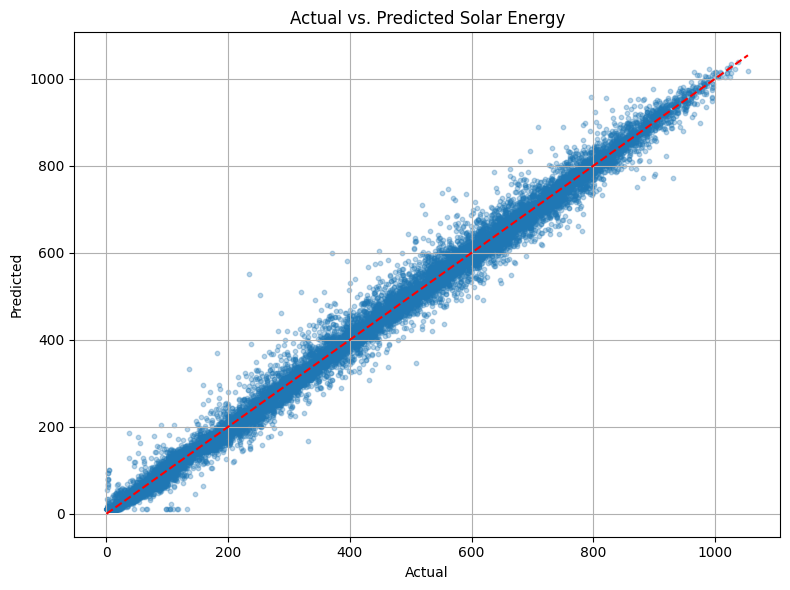

In [36]:
evaluate_and_plot(model=model,val_loader=val_loader,device='cuda')

In [19]:
from fetch import fetch_and_save

In [20]:
df = fetch_and_save(
        parameter="ALLSKY_SFC_SW_DWN",  # Global solar radiation (W/m^2)
        latitude=18.5204,               # Pune latitude
        longitude=73.8567,              # Pune longitude
        location_name="Pune",
        days_ago=4
    )

🔍 Fetching ALLSKY_SFC_SW_DWN from 4 days ago for Pune
📡 Request: https://power.larc.nasa.gov/api/temporal/hourly/point?parameters=ALLSKY_SFC_SW_DWN&community=RE&latitude=18.5204&longitude=73.8567&start=20250729&end=20250729&format=JSON


In [27]:
len(df)

2